In [84]:
from firedrake import *
from firedrake.output import VTKFile
import matplotlib.pyplot as plt
import numpy as np
from firedrake.petsc import PETSc
# Get current path: all relative paths that you may use for input/output start from here.
#
# - Colab:  The default path is /content, and your GDrive folder is accessible (if mounted) at /content/drive/MyDrive
#
# - local:  If running on your local machine, current_path is the position WHERE YOU LAUNCHED THE NOTEBOOK KERNEL BY 'jupyter notebook'
#           and NOT the directory in which this ipynb file is saved.
#           If you want to modify your current path, go to the terminal, stop the kernel (ctrl-C + press y), then move to the desired path by
#           cd my/desired/path/starting/from/here
#           and then launch 'jupyter notebook'.
import os
current_path = os.getcwd()
io_path = current_path + "/cfd-labs/Lab07-NS-nonlinear/"
print(io_path)

/home/aless/cfd-labs/Lab07-NS-nonlinear/



# Ex.1 NS: fixed-point (Picard) method.

We focus our attention on the steady Navier-Stokes equations

\begin{equation*}
\begin{cases}
(\boldsymbol{u}\cdot\nabla)\boldsymbol{u} - \nu\Delta \boldsymbol{u} + \nabla  p  = \boldsymbol{0} & {\rm in} \ \Omega, \\
{\rm div}\,\boldsymbol{u} = 0 & {\rm in} \ \Omega, \\
\boldsymbol{u} = 4y(1-y)\boldsymbol{i} & {\rm on} \ \Gamma_{\rm in}, \\
(\nu\nabla\boldsymbol{u} - pI)\boldsymbol{n} = \boldsymbol{0} & {\rm on} \ \Gamma_{\rm out}, \\
\boldsymbol{u} = \boldsymbol{0} & {\rm on} \ \Gamma_{\rm wall}=\partial\Omega\setminus(\Gamma_{\rm in}\cup\Gamma_{\rm out}). \\
\end{cases}
\end{equation*}

and we want to solve them using the fixed-point method.

firedrake:WARNING Subdomain (1,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (2,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (3,) is empty. This is likely an error. Did you choose the right label?


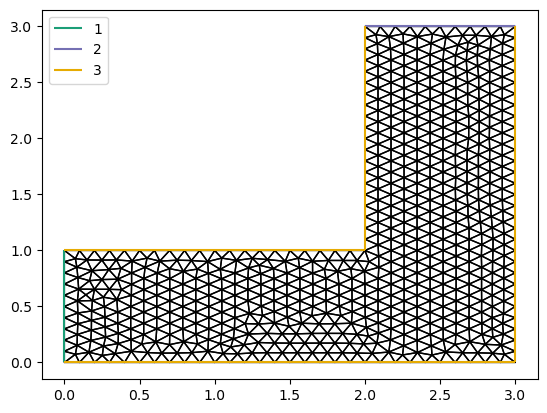

In [85]:
# Import mesh: set the path correctly!
# See cell before Exercise 1 about current path.
mesh = Mesh(io_path + 'mesh/elbow1.msh')
# mesh = Mesh(io_path + 'elbow2.msh')
# mesh = Mesh(io_path + 'elbow3.msh')
fig, ax = plt.subplots()
triplot(mesh, axes=ax)
ax.legend(loc='upper left')

In [87]:
# Function spaces (mixed formulation)
Q = FunctionSpace(mesh, "P", 1)
V = VectorFunctionSpace(mesh, "P", 2)
W = MixedFunctionSpace([V, Q])

# Viscosity and source term
nu = 0.01
f = Constant((0.,0.))

# Boundary conditions: 1=Inlet, 2=Outlet, 3=Wall
x = SpatialCoordinate(mesh)
u_in = (4*x[1]*(1-x[1]), 0.)
bc_wall = DirichletBC(W.sub(0), Constant((0., 0.)), 3)
bc_in = DirichletBC(W.sub(0), u_in, 1)
bcs = [bc_wall, bc_in]

# Variational problems
u, p = TrialFunctions(W)
v, q = TestFunctions(W)

def initialization_problem_forms(u, v, p, q, nu, f):
    """
    Initialize the problem by solving the Stokes equations (linearized Navier-Stokes).
    """
    # Stokes initialization
    a_stokes = Constant(nu) * inner(grad(u), grad(v)) * dx - div(v) * p * dx + q * div(u) * dx
    L_stokes = dot(f, v) * dx
    return a_stokes, L_stokes

def nonlinear_iteration_forms(u, v, p, q, nu, f, u_old):
    """
    Nonlinear iteration: solve the Navier-Stokes equations using Picard iteration.
    """
    # Fixed-point iteration
    a_fp = Constant(nu) * inner(grad(u), grad(v)) * dx  + inner(dot(grad(u), u_old), v) * dx  - div(v) * p * dx  + q * div(u) * dx
    L_fp = dot(f, v) * dx
    return a_fp, L_fp

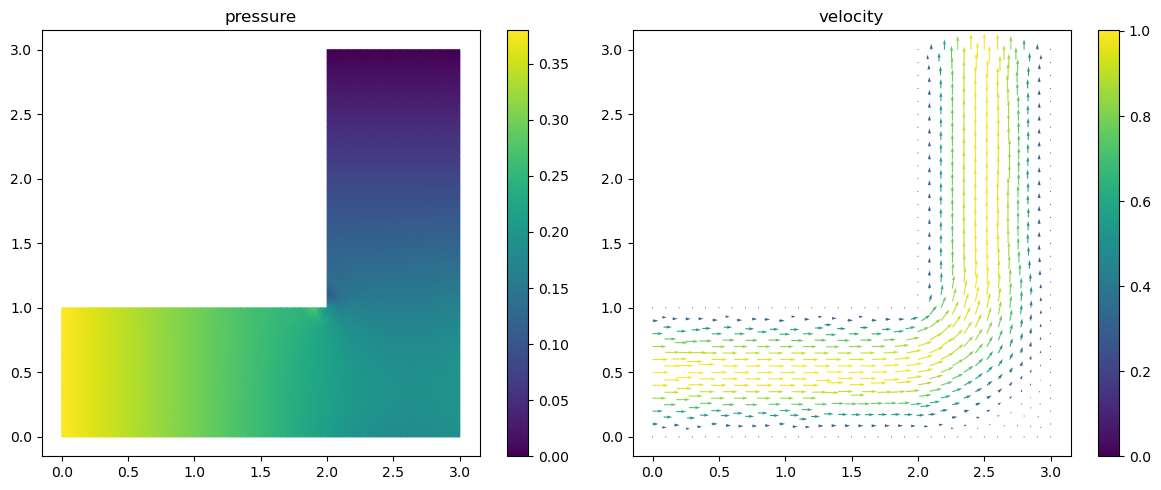

In [98]:
# Initialization: solve Stokes problem to get initial guess
wh_init = Function(W)
a_init, L_init = initialization_problem_forms(u, v, p, q, nu, f)
init_problem = LinearVariationalProblem(a_init, L_init, wh_init, bcs=bcs)
param = {'ksp_type': 'preonly', 'pc_type': 'lu', 'pc_factor_mat_solver_type': 'mumps'}
solver_init =  LinearVariationalSolver(init_problem, solver_parameters=param)
solver_init.solve()
uh, ph = wh_init.subfunctions

# Plot of initial guess
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

col0 = tripcolor(ph, axes=ax[0])
fig.colorbar(col0, ax=ax[0])
ax[0].set_title('pressure')

col1 = quiver(uh, axes=ax[1])
fig.colorbar(col1, ax=ax[1])
ax[1].set_title('velocity')

plt.tight_layout()

# vtk output for Paraview
from firedrake.output import VTKFile
outfile = VTKFile(io_path + "output/solution.pvd")
uh.rename("Velocity")
ph.rename("Pressure")
outfile.write(uh, ph)

# Nonlinear solver
u_old = Function(V)
u_old.assign(uh)
p_old = Function(Q)
p_old.assign(ph)
a, L = nonlinear_iteration_forms(u, v, p, q, nu, f, u_old)
wh = Function(W)
problem = LinearVariationalProblem(a, L, wh, bcs=bcs)
solver =  LinearVariationalSolver(problem, solver_parameters=param)

In [99]:
# Iterative algorithm

maxit = 100
it = 0
tol = 1e-3
err = tol + 1     # >tol in order to enter the loop at the beginning

while it <= maxit and err > tol:
    it += 1

    # solve problem and compute error
    solver.solve()
    uh, ph = wh.subfunctions
    err = errornorm(uh, u_old, 'H1') / norm(u_old, 'H1') + errornorm(ph, p_old, 'L2') / norm(p_old, 'L2')

    print("--------------------------------")
    print(f"Step : {it}")
    print(f"Error: {err}")
    uh.rename("Velocity")
    ph.rename("Pressure")
    outfile.write(uh, ph)

    # update the old solution
    u_old.assign(uh)
    p_old.assign(ph)

print("--------------------------------")

if it <= maxit:
    print('Nonlinear solver converged in', it, 'iterations.')
else:
    print('Nonlinear solver did NOT converge!\nRelative error =', err, 'after', it, 'iterations.')
print("--------------------------------")

--------------------------------
Step : 1
Error: 1.0937381047680383
--------------------------------
Step : 2
Error: 0.31549136525218135
--------------------------------
Step : 3
Error: 0.1701465199056268
--------------------------------
Step : 4
Error: 0.07509143804748138
--------------------------------
Step : 5
Error: 0.023279958201429654
--------------------------------
Step : 6
Error: 0.006135739966875324
--------------------------------
Step : 7
Error: 0.0020166581650156766
--------------------------------
Step : 8
Error: 0.0007659301426194836
--------------------------------
Nonlinear solver converged in 8 iterations.
--------------------------------


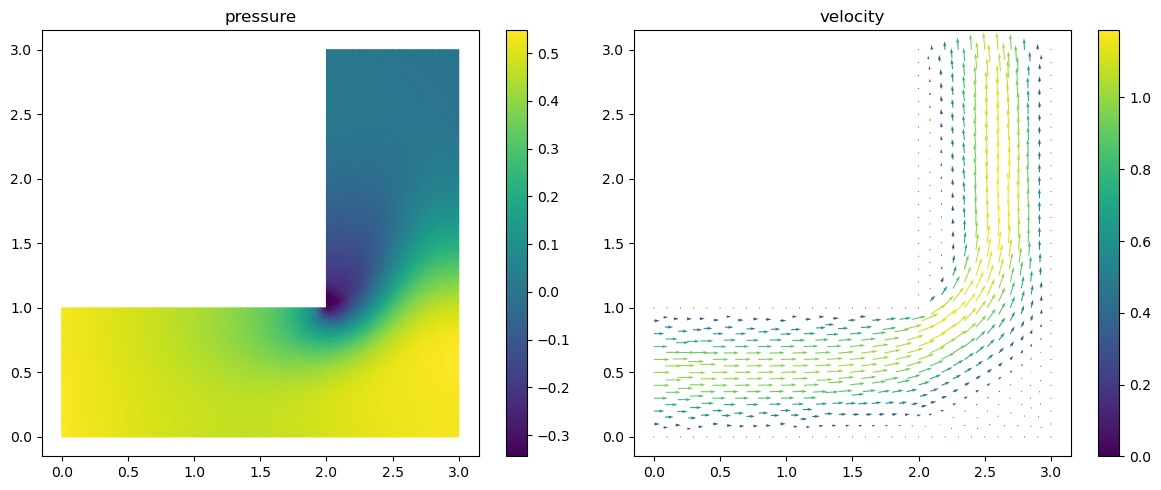

In [97]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

col0 = tripcolor(ph, axes=ax[0])
fig.colorbar(col0, ax=ax[0])
ax[0].set_title('pressure')

col1 = quiver(uh, axes=ax[1])
fig.colorbar(col1, ax=ax[1])
ax[1].set_title('velocity')

plt.tight_layout()